<a href="https://colab.research.google.com/github/raheelam98/DataAnalysis/blob/main/EDA/EDA_Sessions_RM/DA5_Missing_values_and_outliers_Sec_3_RM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data loading

#### Subtask:
Load the data from the provided CSV file into a pandas DataFrame.


Reasoning: Load the data from the provided CSV file into a pandas DataFrame and display the first few rows.

In [41]:
import pandas as pd

df = pd.read_csv('/content/sample_data/EDA/bus_fare_dataset.csv')

display(df.head())

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


### Data exploration

#### Subtask:
Explore the loaded data to understand its structure and basic statistics.


## Data exploration

### Subtask:
Explore the loaded data to understand its structure and basic statistics.


In [42]:
# Check dimensions
print("Shape of the DataFrame:\n", df.shape)

# Examine data types
print("\n\nData types of each column:\n")
print(df.info())

# Descriptive statistics for numerical columns
print("\n\nDescriptive statistics for numerical columns:\n")
print(df.describe())

# Display first few rows
print("\n\nFirst few rows of the DataFrame:\n")
display(df.head())


Shape of the DataFrame:
 (418, 11)


Data types of each column:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
None


Descriptive statistics for numerical columns:

       PassengerId      Pclass         Age       SibSp       Parch        Fare
count   418.000000  418.000000  332.000000  418.000000  418.000000  417.000000
mean   11

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [43]:
# Unique values in categorical columns
print("\nUnique values in categorical columns:")
for col in ['Sex', 'Embarked']:  # Example categorical columns
    print(f"\nColumn '{col}':")
    print(df[col].unique())
    print(df[col].value_counts())


Unique values in categorical columns:

Column 'Sex':
['male' 'female']
Sex
male      266
female    152
Name: count, dtype: int64

Column 'Embarked':
['Q' 'S' 'C']
Embarked
S    270
C    102
Q     46
Name: count, dtype: int64


In [21]:
df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

**RM Notes**

### **nunique() -  value_counts()**

 **`df['ColumnName'].nunique() `**

 Returns the **number of unique values** in the specified column of a Pandas DataFrame.


Use When :

- You want to know how many distinct categories or values a column has.

- Helpful for categorical variables and feature engineering (e.g., encoding).


**` df['ColumnName'].value_counts() `**

Returns a **count of each unique value** in a Series (i.e., a column of a DataFrame), sorted in descending order by default.


In [22]:
# Return a Series containing counts of unique values.
df['Sex'].value_counts()

,count
Sex,
male,266
female,152


In [26]:
# Return a Series containing counts of unique values.
df['Cabin'].value_counts()

,count
Cabin,
B57 B59 B63 B66,3
B45,2
C23 C25 C27,2
C78,2
C31,2
...,...
B41,1
C7,1
D40,1


In [28]:
df['SibSp'].value_counts()

,count
SibSp,
0,283
1,110
2,14
3,4
4,4
8,2
5,1


In [29]:
df['Parch'].value_counts()

,count
Parch,
0,324
1,52
2,33
3,3
4,2
9,2
6,1
5,1


In [30]:
df['Parch'].unique()

array([0, 1, 3, 2, 4, 6, 5, 9])

In [32]:
# Returns the number of unique values in the column of a DataFrame
df['Parch'].nunique()

8

In [35]:
for col in df.columns:  # Example categorical columns
    print(f"\nColumn '{col}':")
    print("nunique :",df[col].nunique())
    print("value_counts :",df[col].value_counts())
    print("---------------------------------------------\n")


Column 'PassengerId':
nunique : 418
value_counts : PassengerId
1309    1
892     1
1293    1
1292    1
1291    1
       ..
898     1
897     1
896     1
895     1
894     1
Name: count, Length: 418, dtype: int64
---------------------------------------------


Column 'Pclass':
nunique : 3
value_counts : Pclass
3    218
1    107
2     93
Name: count, dtype: int64
---------------------------------------------


Column 'Name':
nunique : 418
value_counts : Name
Peter, Master. Michael J                        1
Kelly, Mr. James                                1
Gale, Mr. Harry                                 1
Bonnell, Miss. Caroline                         1
Conlon, Mr. Thomas Henry                        1
                                               ..
Connolly, Miss. Kate                            1
Svensson, Mr. Johan Cervin                      1
Hirvonen, Mrs. Alexander (Helga E Lindqvist)    1
Wirz, Mr. Albert                                1
Myles, Mr. Thomas Francis             

**RM Notes**

**` df.isnull() `**

Returns a DataFrame of the same shape as df, where each cell is:

- True if the value is missing (NaN)
- False if the value is present

### **Count missing values in each column :**

**` df.isnull().sum() `**


In [44]:
#age fare and cabin -- missing values in each column
df.isnull().sum()
#age % missing value-- no of missing value/ total data *100

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [46]:
#% of missing values in a column
missing_values = df.isnull().sum() # how many missing values in the column

missing_percentage = (missing_values / len(df)) * 100 # len----> no of rows

print("\nMissing Value Percentage:\n\n", missing_percentage)

## % missing value-- no of missing value/ total data *100


Missing Value Percentage:

 PassengerId     0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64


**RM Notes**

A **histogram displays** the distribution of a single numeric variable by showing the **frequency of values within continuous intervals** (bins).

- Single numerical variable: Yes — histograms are for one continuous variable.

- Frequency: Yes — it shows how often values occur within each interval.

- Continuous intervals (bins): Yes — the x-axis is split into equal-width ranges.



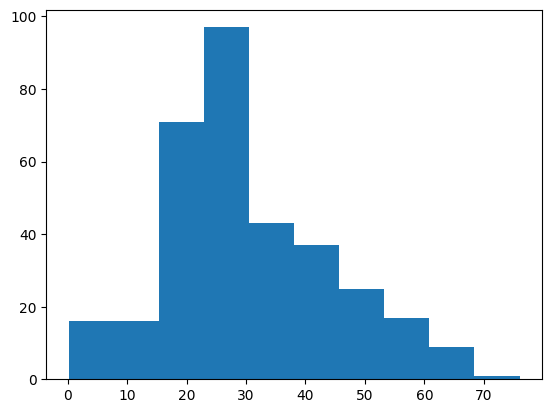

In [47]:
#fare and age imputation--- continous --- shape of the column
#histogram making
import matplotlib.pyplot as plt

plt.hist(df["Age"])
plt.show() # plot to show
